## Import Required Libraries

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 15,
    "axes.labelweight": "bold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13
})

## Load Dataset and Encode Labels

In [14]:
data = load_breast_cancer()

X = data.data
y = data.target   # Already encoded (0 = malignant, 1 = benign)

feature_names = data.feature_names
target_names = data.target_names

print("Dataset Shape:", X.shape)
print("Target Classes:", target_names)

Dataset Shape: (569, 30)
Target Classes: ['malignant' 'benign']


## Exploratory Data Analysis (EDA)

#### Class Distribution

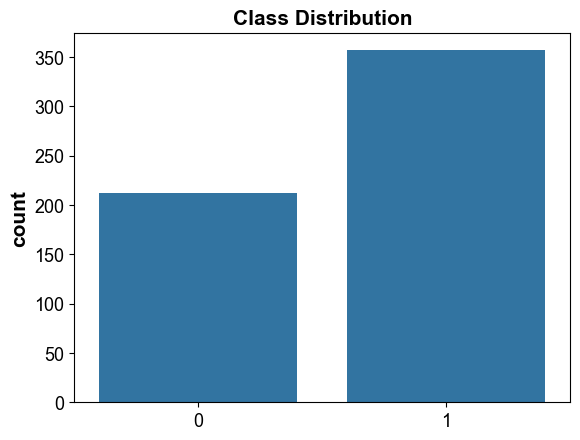

In [15]:
plt.figure()
sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()

#### Correlation Heatmap

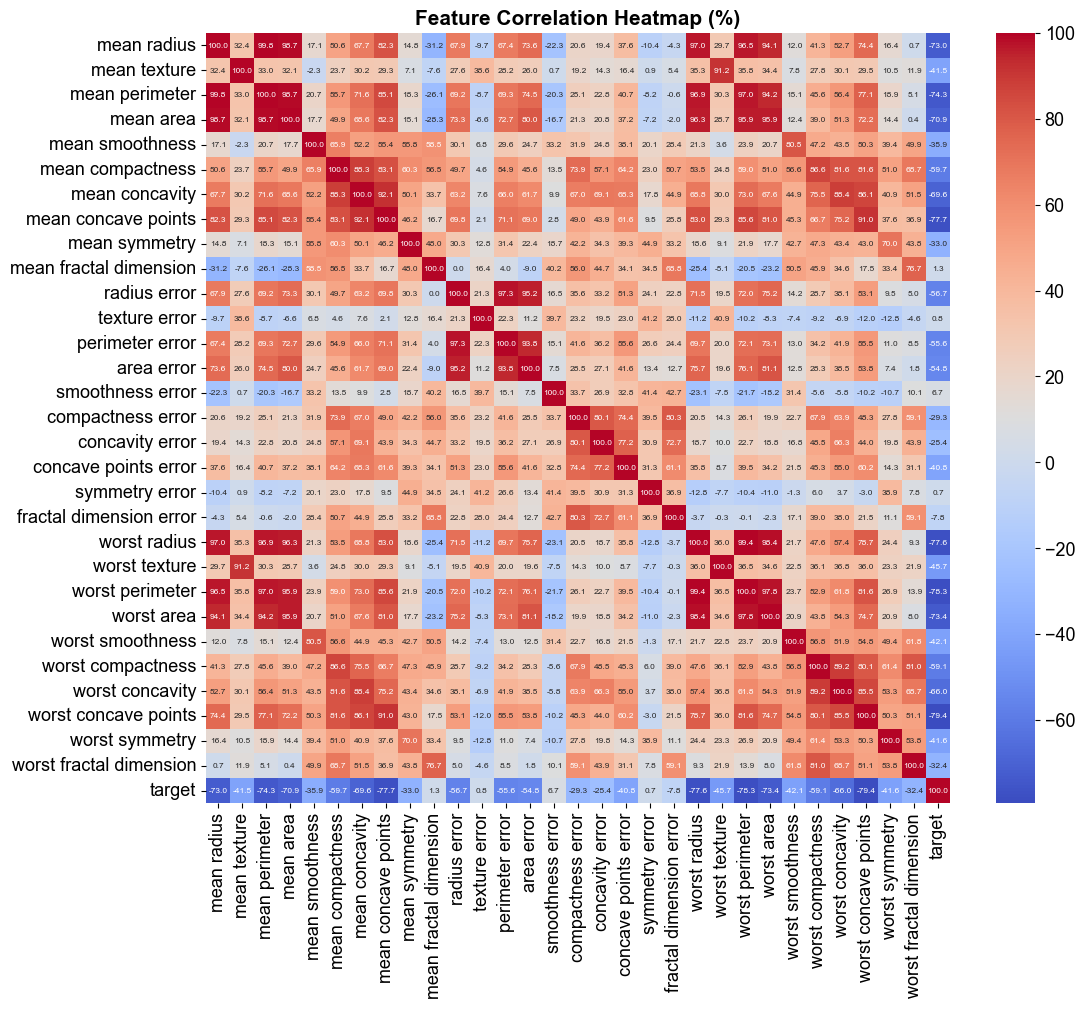

In [16]:
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Compute correlation matrix
corr_matrix = df.corr() * 100   # Convert to percentage

plt.figure(figsize=(12,10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True,          # Show values
    fmt=".1f",           # 1 decimal place
    annot_kws={"size":6}
)

plt.title("Feature Correlation Heatmap (%)")
plt.show()

## Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (455, 30)
Testing size: (114, 30)


## Train Decision Tree Classifier

In [18]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

## Hyperparameter Search Space (Decision Tree)

In [19]:
dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

## 5-Fold Cross Validation for Decision Tree

In [20]:
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=1
)

dt_grid.fit(X_train, y_train)
bestParam_DT = dt_grid.best_params_

acc_scores_dt = cross_val_score(dt, X_train, y_train, cv=5, scoring='accuracy')
f1_scores_dt = cross_val_score(dt, X_train, y_train, cv=5, scoring='f1')

print("Best Parameters (Decision Tree):", bestParam_DT)
print("Best CV Accuracy:", dt_grid.best_score_)

Best Parameters (Decision Tree): {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV Accuracy: 0.9384615384615385


In [21]:
dt_table = pd.DataFrame({
    "Criterion": [bestParam_DT["criterion"]],
    "Max Depth" : [bestParam_DT["max_depth"]],
    "Min_samples_leaf":[bestParam_DT["min_samples_leaf"]],
    "Min_samples_split": [bestParam_DT["min_samples_split"]],
    "Average CV Accuracy %": [acc_scores_dt.mean()*100],
    "Average CV f1 Score" : [f1_scores_dt.mean()]
})
dt_table

,Criterion,Max Depth,Min_samples_leaf,Min_samples_split,Average CV Accuracy %,Average CV f1 Score
0,gini,5,1,5,90.989011,0.928176


In [22]:
## Best Model
best_dt = dt_grid.best_estimator_
print(best_dt)

DecisionTreeClassifier(max_depth=5, min_samples_split=5, random_state=42)


## Train Random Forest Classifier

In [23]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## Hyperparameter Tuning for Random Forest

In [24]:
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=1
)

rf_grid.fit(X_train, y_train)
bestParam_RF = rf_grid.best_params_

print("Best Parameters (Random Forest):", bestParam_RF)
print("Best CV Accuracy:", rf_grid.best_score_)

Best Parameters (Random Forest): {'bootstrap': False, 'max_depth': None, 'max_features': 'log2', 'n_estimators': 100}
Best CV Accuracy: 0.9692307692307693


In [25]:
acc_scores_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
f1_scores_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1')

rf_table = pd.DataFrame({
    "n_estimators": [bestParam_RF["n_estimators"]],
    "Max Depth" : [bestParam_RF["max_depth"]],
    "Max Features" : [bestParam_RF["max_features"]],
    "Boostrap": [bestParam_RF["bootstrap"]],
    "Average CV Accuracy %": [acc_scores_rf.mean()*100],
    "Average CV f1 Score" : [f1_scores_rf.mean()]
})
rf_table

,n_estimators,Max Depth,Max Features,Boostrap,Average CV Accuracy %,Average CV f1 Score
0,100,None,log2,False,95.384615,0.963408


In [26]:
## Best Model 
best_rf = rf_grid.best_estimator_

## 5-Fold Cross Validation Comparison

In [27]:
dt_cv_scores = cross_val_score(best_dt, X_train, y_train, cv=5)
rf_cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5)


compare_table = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Fold 1": [dt_cv_scores[0], rf_cv_scores[0]],
    "Fold 2": [dt_cv_scores[1], rf_cv_scores[1]],
    "Fold 3": [dt_cv_scores[2], rf_cv_scores[2]],
    "Fold 4": [dt_cv_scores[3], rf_cv_scores[3]],
    "Fold 5": [dt_cv_scores[4], rf_cv_scores[4]],
    "Average": [dt_cv_scores.mean(), rf_cv_scores.mean()]
})
compare_table

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
0,Decision Tree,0.945055,0.945055,0.901099,0.945055,0.956044,0.938462
1,Random Forest,0.978022,1.000000,0.934066,0.956044,0.978022,0.969231


## Evaluation Metrics (Test Set)

In [28]:
# Decision Tree
y_pred_dt = best_dt.predict(X_test)
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90        42
           1       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



In [29]:
# Random Forest
y_pred_rf = best_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [30]:
from sklearn.metrics import roc_auc_score

# Probabilities for positive class (class = 1)
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# ROC AUC scores
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

evaluate = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf)],
    "Precision": [precision_score(y_test, y_pred_dt), precision_score(y_test, y_pred_rf)],
    "Recall": [recall_score(y_test, y_pred_dt), recall_score(y_test, y_pred_rf)],
    "F1 Score": [f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_rf)],
    "ROC AUC": [roc_auc_dt, roc_auc_rf]
})

evaluate

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Decision Tree,0.921053,0.956522,0.916667,0.936170,0.916336
1,Random Forest,0.956140,0.958904,0.972222,0.965517,0.994378


## Confusion Matrix

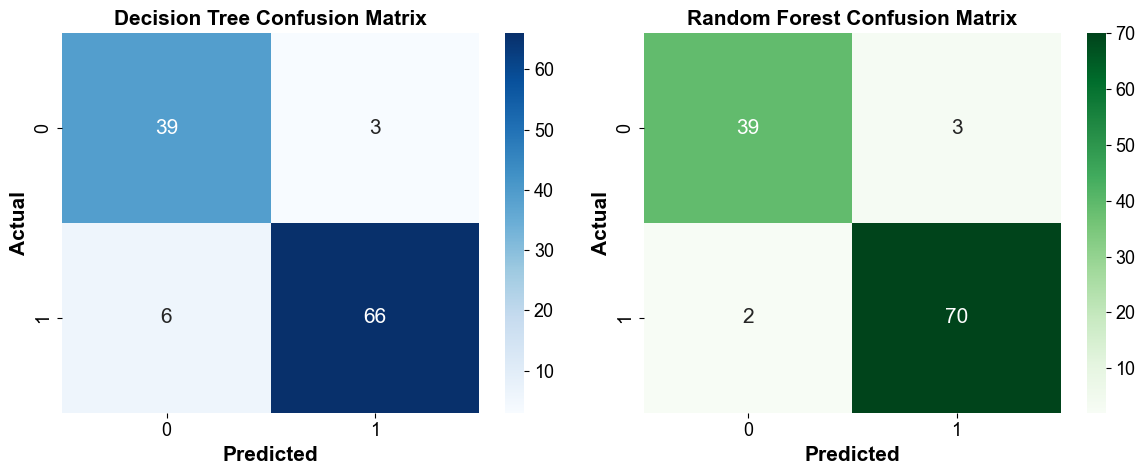

In [31]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Decision Tree
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            ax=axes[0])
axes[0].set_title("Decision Tree Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            ax=axes[1])
axes[1].set_title("Random Forest Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## ROC Curve and AUC

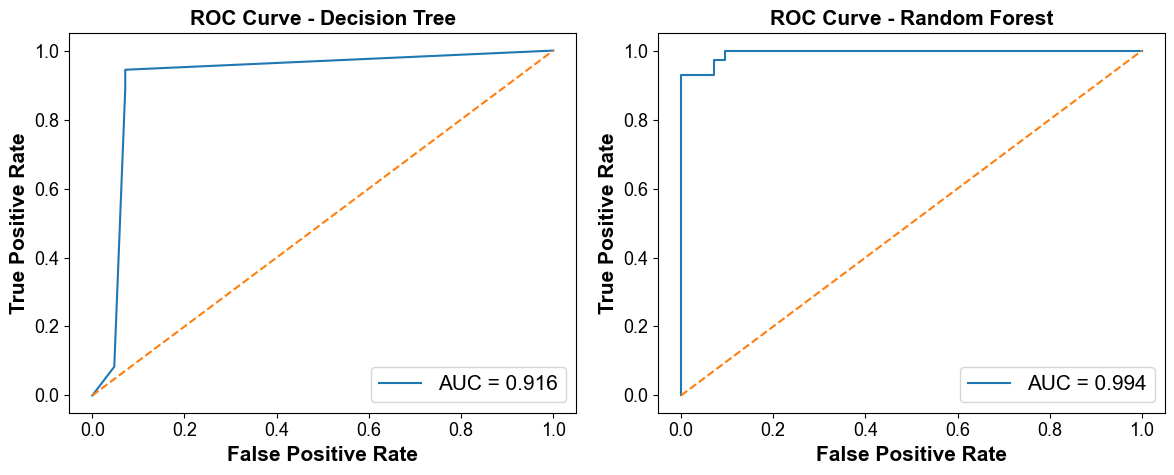

In [33]:
# ==============================
# ROC CURVES — DT vs RF (SUBPLOTS)
# ==============================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# -----------------------------
# Decision Tree
# -----------------------------
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# -----------------------------
# Random Forest
# -----------------------------
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# -----------------------------
# Create Subplots
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# ---- Decision Tree ROC ----
axes[0].plot(fpr_dt, tpr_dt, label=f"AUC = {roc_auc_dt:.3f}")
axes[0].plot([0,1], [0,1], '--')
axes[0].set_title("ROC Curve - Decision Tree")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# ---- Random Forest ROC ----
axes[1].plot(fpr_rf, tpr_rf, label=f"AUC = {roc_auc_rf:.3f}")
axes[1].plot([0,1], [0,1], '--')
axes[1].set_title("ROC Curve - Random Forest")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()